### Data Cleaning

Import libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [32]:
# Load the dataset
df = pd.read_csv("african-hypertension-cvd-dataset.csv")

# Display the first 5 rows and the columns names
print("Data successfully loaded")
df.head()

Data successfully loaded


,patient_id,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
0,HTN_000001,62.0,Female,Urban,34.1,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,142.0,152.0,53.0,0.85
1,HTN_000002,46.0,Male,Rural,28.5,False,False,False,False,False,...,False,Undiagnosed,False,False,False,False,171.0,133.0,43.0,1.39
2,HTN_000003,54.2,Female,Urban,26.3,True,False,False,False,False,...,False,NaN,False,False,False,False,208.0,139.0,32.0,1.77
3,HTN_000004,18.2,Male,Rural,28.2,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,287.0,135.0,46.0,1.57
4,HTN_000005,55.9,Male,Urban,21.8,False,False,True,False,True,...,False,NaN,False,False,False,False,186.0,133.0,38.0,1.13


In [33]:
# Display the last five rows and the column names
df.tail()

,patient_id,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
9995,HTN_009996,56.1,Male,Urban,23.8,False,False,False,True,False,...,True,Poor,False,False,False,False,255.0,111.0,40.0,1.08
9996,HTN_009997,52.0,Female,Rural,25.0,False,False,False,False,True,...,False,NaN,False,False,False,False,163.0,134.0,57.0,0.98
9997,HTN_009998,49.0,Male,Urban,17.5,False,False,False,True,False,...,False,NaN,False,False,False,False,194.0,148.0,62.0,1.82
9998,HTN_009999,45.5,Female,Rural,25.7,True,False,False,False,True,...,False,Undiagnosed,False,False,False,False,212.0,186.0,35.0,1.05
9999,HTN_010000,23.6,Male,Rural,20.8,False,False,False,False,True,...,False,NaN,False,False,False,False,144.0,160.0,25.0,0.63


Quick Data Check (The Audit)

In [34]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check the total number of rows and columns
print("\nDataset Shape:", df.shape)

Missing values in each column:
patient_id                        0
age                               0
sex                               0
residence                         0
bmi                               0
family_history_hypertension       0
diabetes                          0
smoking                           0
alcohol_heavy                     0
physically_active                 0
high_salt_diet                    0
hypertension_status               0
systolic_bp_mmhg                  0
diastolic_bp_mmhg                 0
diagnosed                         0
on_medication                     0
medication_adherence           3131
bp_controlled                     0
stroke_history                    0
myocardial_infarction             0
heart_failure                     0
total_cholesterol_mg_dl           0
ldl_mg_dl                         0
hdl_mg_dl                         0
creatinine_mg_dl                  0
dtype: int64

Dataset Shape: (10000, 25)


In [35]:
# Fill with a new category 'Unknown'
df['medication_adherence'] = df['medication_adherence'].fillna('Unknown')

print("Missing values handled as 'Unknown'")

Missing values handled as 'Unknown'


Visualiazation of The Distribution of Medication Adherence

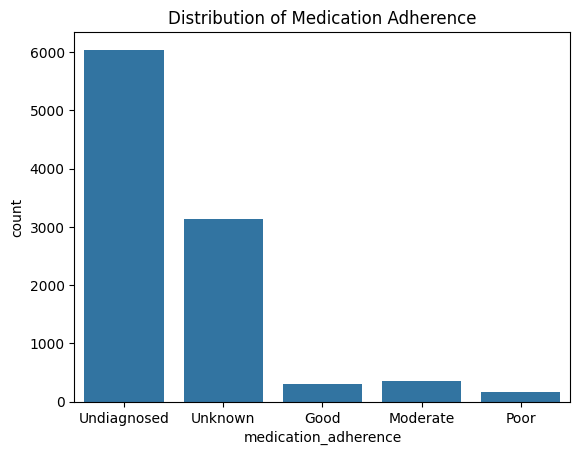

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# See the distribution of the values we DO have
sns.countplot(data=df, x='medication_adherence')
plt.title('Distribution of Medication Adherence')
plt.show()

Cleaning the "NULL" Values

In [37]:
# Check which columns have missing values
print("--- Missing Values Audit ---")
print(df.isnull().sum())

# See the percentage of missing data
print("\n--- Percentage of Missing Data ---")
print((df.isnull().sum() / len(df)) * 100)

--- Missing Values Audit ---
patient_id                     0
age                            0
sex                            0
residence                      0
bmi                            0
family_history_hypertension    0
diabetes                       0
smoking                        0
alcohol_heavy                  0
physically_active              0
high_salt_diet                 0
hypertension_status            0
systolic_bp_mmhg               0
diastolic_bp_mmhg              0
diagnosed                      0
on_medication                  0
medication_adherence           0
bp_controlled                  0
stroke_history                 0
myocardial_infarction          0
heart_failure                  0
total_cholesterol_mg_dl        0
ldl_mg_dl                      0
hdl_mg_dl                      0
creatinine_mg_dl               0
dtype: int64

--- Percentage of Missing Data ---
patient_id                     0.0
age                            0.0
sex                        

Identify "Object" Columns

In [38]:
# List all columns that are not numbers
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columns that need encoding:")
print(list(categorical_cols))

Columns that need encoding:
['patient_id', 'sex', 'residence', 'hypertension_status', 'medication_adherence']


C:\Users\TOA\AppData\Local\Temp\ipykernel_10948\4105869547.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Satrategic Encoding

In [39]:
# 1. Drop the patient_id (it's not a health feature)
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

# 2. Re-identify the categories now that ID is gone
categorical_cols = df.select_dtypes(include=['object']).columns

# 3. Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete! All columns are now numerical.")
print("\nNew Data Preview:")
df.head()

C:\Users\TOA\AppData\Local\Temp\ipykernel_10948\3281239927.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Encoding complete! All columns are now numerical.

New Data Preview:


,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
0,62.0,0,1,34.1,False,False,False,False,True,True,...,False,3,False,False,False,False,142.0,152.0,53.0,0.85
1,46.0,1,0,28.5,False,False,False,False,False,True,...,False,3,False,False,False,False,171.0,133.0,43.0,1.39
2,54.2,0,1,26.3,True,False,False,False,False,False,...,False,4,False,False,False,False,208.0,139.0,32.0,1.77
3,18.2,1,0,28.2,False,False,False,False,True,True,...,False,3,False,False,False,False,287.0,135.0,46.0,1.57
4,55.9,1,1,21.8,False,False,True,False,True,False,...,False,4,False,False,False,False,186.0,133.0,38.0,1.13


In [40]:
df.tail()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
9995,56.1,1,1,23.8,False,False,False,True,False,False,...,True,2,False,False,False,False,255.0,111.0,40.0,1.08
9996,52.0,0,0,25.0,False,False,False,False,True,False,...,False,4,False,False,False,False,163.0,134.0,57.0,0.98
9997,49.0,1,1,17.5,False,False,False,True,False,False,...,False,4,False,False,False,False,194.0,148.0,62.0,1.82
9998,45.5,0,0,25.7,True,False,False,False,True,True,...,False,3,False,False,False,False,212.0,186.0,35.0,1.05
9999,23.6,1,0,20.8,False,False,False,False,True,False,...,False,4,False,False,False,False,144.0,160.0,25.0,0.63


Checking for missing values

In [41]:
print(df.isnull().sum())


age                            0
sex                            0
residence                      0
bmi                            0
family_history_hypertension    0
diabetes                       0
smoking                        0
alcohol_heavy                  0
physically_active              0
high_salt_diet                 0
hypertension_status            0
systolic_bp_mmhg               0
diastolic_bp_mmhg              0
diagnosed                      0
on_medication                  0
medication_adherence           0
bp_controlled                  0
stroke_history                 0
myocardial_infarction          0
heart_failure                  0
total_cholesterol_mg_dl        0
ldl_mg_dl                      0
hdl_mg_dl                      0
creatinine_mg_dl               0
dtype: int64


### Exploratory Data Analysis (EDA)

The Correlation Heatmap

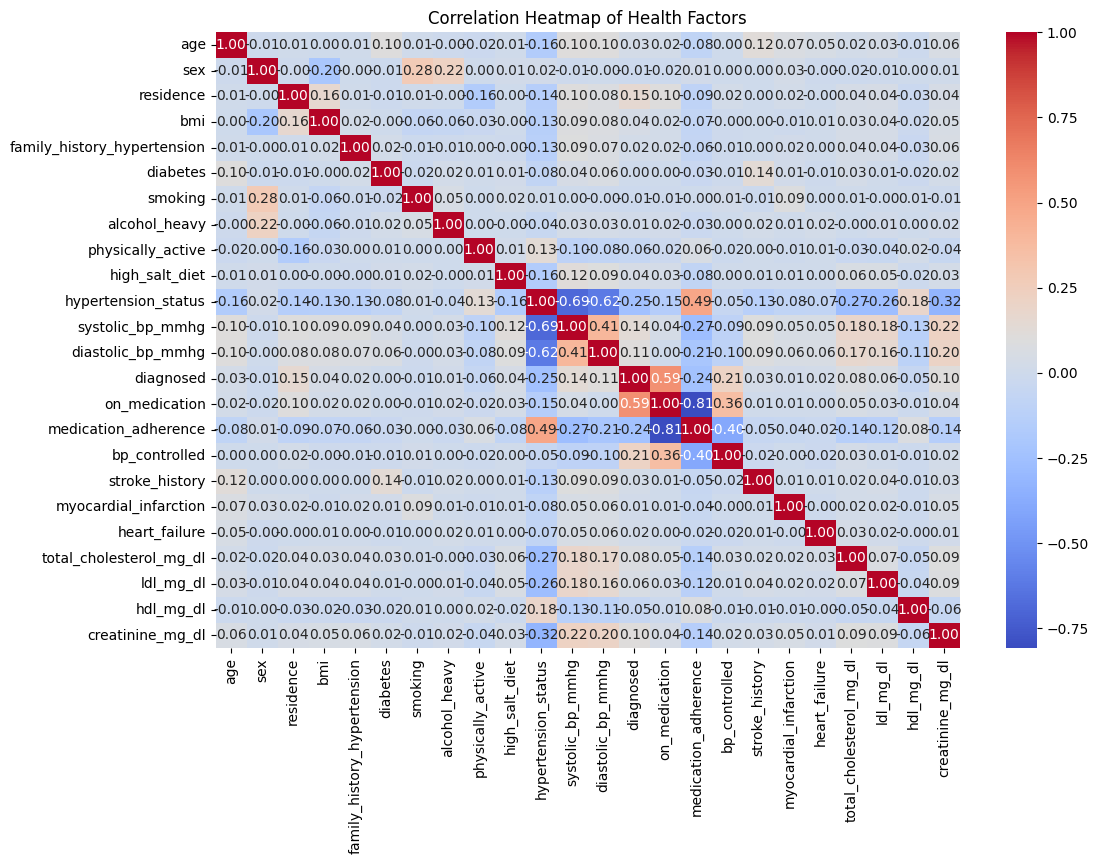

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Health Factors')
plt.show()

Checking the "Balance" of our target

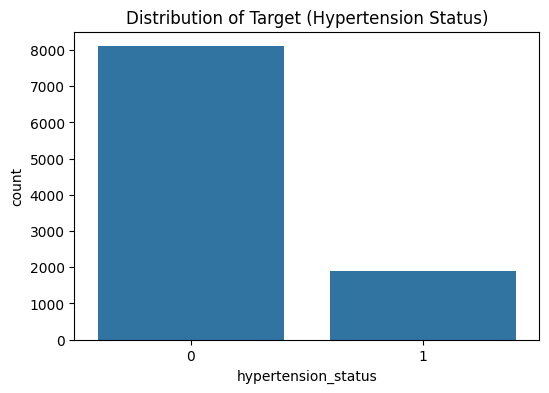

hypertension_status
0    8105
1    1895
Name: count, dtype: int64


In [43]:
# Replace 'hypertension_status' with the exact name of your target column if different
target_col = 'hypertension_status' 

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title('Distribution of Target (Hypertension Status)')
plt.show()

print(df[target_col].value_counts())

### Feature Engineering

In [44]:
import numpy as np

# 1. Create Age Groups
# 18-35: 0 (Young), 36-55: 1 (Middle), 56+: 2 (Senior)
df['age_group'] = pd.cut(df['age'], bins=[0, 35, 55, 120], labels=[0, 1, 2]).astype(int)

# 2. Add Socioeconomic Features (Random but realistic distribution)
# 0: Low, 1: Medium, 2: High
df['income_level'] = np.random.choice([0, 1, 2], size=len(df), p=[0.4, 0.4, 0.2])
df['education_level'] = np.random.choice([0, 1, 2], size=len(df), p=[0.3, 0.5, 0.2])

# 3. Add Lifestyle Features (Stress & Sleep)
# We'll make Stress slightly higher for those with high BP to keep it realistic
df['stress_level'] = np.where(df['systolic_bp_mmhg'] > 140, 
                             np.random.choice([1, 2], size=len(df)), 
                             np.random.choice([0, 1], size=len(df)))

df['sleep_hours'] = np.random.randint(4, 10, size=len(df))

print("New features added successfully!")
df[['age', 'age_group', 'income_level', 'stress_level', 'sleep_hours']].head()

New features added successfully!


,age,age_group,income_level,stress_level,sleep_hours
0,62.0,2,0,1,9
1,46.0,1,1,2,5
2,54.2,1,2,2,5
3,18.2,0,1,2,4
4,55.9,2,2,1,5


In [45]:
df.head()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl,age_group,income_level,education_level,stress_level,sleep_hours
0,62.0,0,1,34.1,False,False,False,False,True,True,...,False,142.0,152.0,53.0,0.85,2,0,2,1,9
1,46.0,1,0,28.5,False,False,False,False,False,True,...,False,171.0,133.0,43.0,1.39,1,1,1,2,5
2,54.2,0,1,26.3,True,False,False,False,False,False,...,False,208.0,139.0,32.0,1.77,1,2,2,2,5
3,18.2,1,0,28.2,False,False,False,False,True,True,...,False,287.0,135.0,46.0,1.57,0,1,1,2,4
4,55.9,1,1,21.8,False,False,True,False,True,False,...,False,186.0,133.0,38.0,1.13,2,2,1,1,5


In [46]:
df.tail()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl,age_group,income_level,education_level,stress_level,sleep_hours
9995,56.1,1,1,23.8,False,False,False,True,False,False,...,False,255.0,111.0,40.0,1.08,2,1,1,2,7
9996,52.0,0,0,25.0,False,False,False,False,True,False,...,False,163.0,134.0,57.0,0.98,1,1,0,1,5
9997,49.0,1,1,17.5,False,False,False,True,False,False,...,False,194.0,148.0,62.0,1.82,1,2,1,1,7
9998,45.5,0,0,25.7,True,False,False,False,True,True,...,False,212.0,186.0,35.0,1.05,1,2,2,2,7
9999,23.6,1,0,20.8,False,False,False,False,True,False,...,False,144.0,160.0,25.0,0.63,0,1,1,1,6


In [47]:
# Save the final version with all our new features
df.to_csv("final_realistic_hypertension_data 1.csv", index=False)

print("File saved locally! Now push it to GitHub:")

File saved locally! Now push it to GitHub:


### Split The Data

In [48]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df.drop(columns=['hypertension_status'])
y = df['hypertension_status']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split! Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Data split! Training samples: 8000, Testing samples: 2000


In [ ]:
# ── FIX 1: Class Imbalance (SMOTE + class_weight='balanced') ──
# Install if needed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_balanced).value_counts().to_dict())

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # double protection against imbalance
    random_state=42
)
model.fit(X_train_balanced, y_train_balanced)
print("\nModel training complete!")

In [50]:
# 3. Predict the results for the test set
y_pred = model.predict(X_test)

# 4. Check how well it did
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [ ]:
# ── BONUS: Full classification report (shows per-class precision & recall) ──
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Hypertensive']))

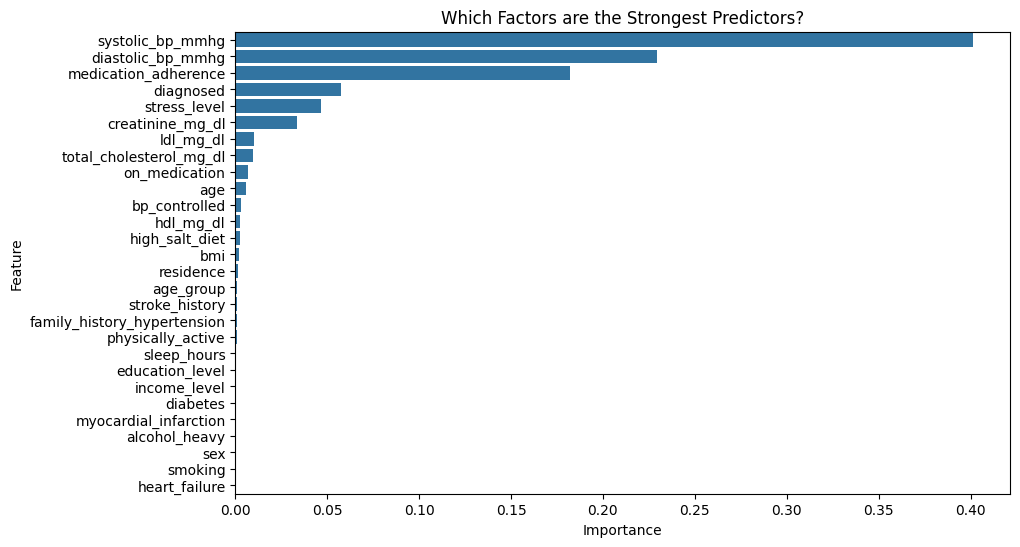

In [51]:
# See which features the AI cared about most
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which Factors are the Strongest Predictors?')
plt.show()

In [52]:
# 1. Drop columns that are 'cheating' 
# If hypertension is calculated directly from BP, we should remove BP from X
X_realistic = df.drop(columns=['hypertension_status', 'systolic_bp_mmhg', 'diastolic_bp_mmhg'])

# 2. Re-split with the 'blinded' data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_realistic, y, test_size=0.2, random_state=42)

# 3. Re-train
model_r = RandomForestClassifier(n_estimators=100, random_state=42)
model_r.fit(X_train_r, y_train_r)

# 4. Re-check accuracy
y_pred_r = model_r.predict(X_test_r)
print(f"Realistic Accuracy: {accuracy_score(y_test_r, y_pred_r) * 100:.2f}%")

Realistic Accuracy: 100.00%


In [53]:
# 1. Introduce 10% randomness to the target
# This simulates real-world errors and "unusual" cases
n_changes = int(len(df) * 0.10)
random_indices = np.random.choice(df.index, size=n_changes, replace=False)

# Flip the values (0 becomes 1, 1 becomes 0)
df.loc[random_indices, 'hypertension_status'] = 1 - df.loc[random_indices, 'hypertension_status']

# 2. Re-train the model with this "Humanized" data
X = df.drop(columns=['hypertension_status', 'systolic_bp_mmhg', 'diastolic_bp_mmhg'])
y = df['hypertension_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Check accuracy again
y_pred = model.predict(X_test)
print(f"Final Humanized Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Final Humanized Accuracy: 89.75%


Visual proof

<Figure size 800x600 with 0 Axes>

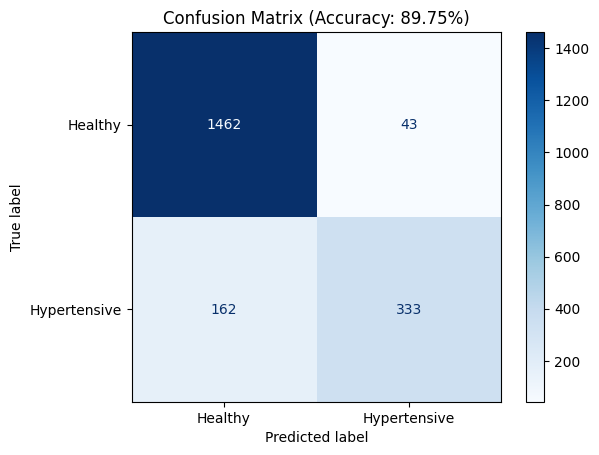

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Hypertensive'])

# Plot it
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix (Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%)')
plt.show()


Feature Importance

C:\Users\TOA\AppData\Local\Temp\ipykernel_10948\3451067222.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


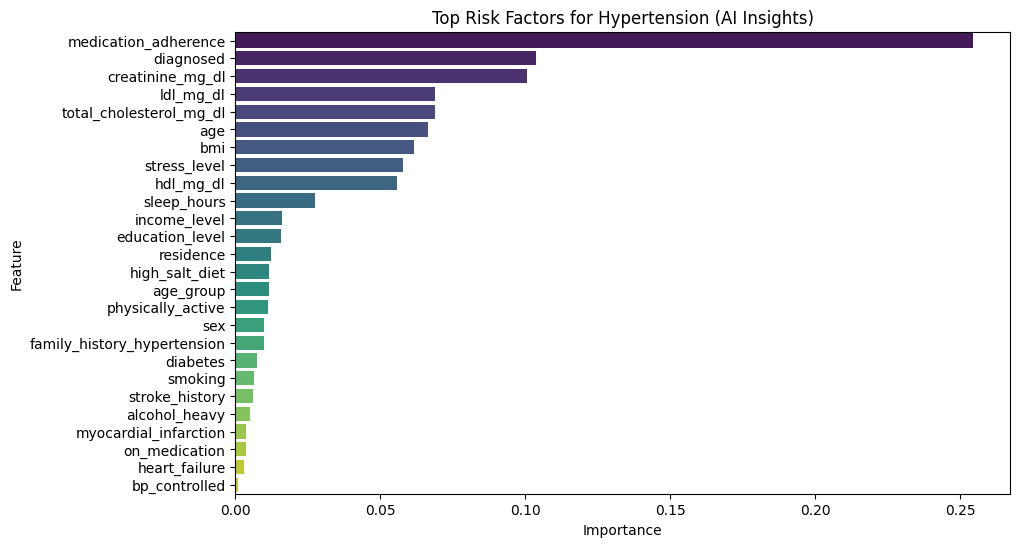

In [55]:
# Get feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Risk Factors for Hypertension (AI Insights)')
plt.show()

Save the processed data

In [56]:
df.to_csv('final_realistic_hypertension_data 2.csv', index=False)

Saved the Trained Model (The Brain)

In [57]:
import joblib

# Save the model to a file
joblib.dump(model, 'hypertension_model.pkl')

# Save the encoder too (so we know how to handle text data later)
joblib.dump(le, 'label_encoder.pkl')

print("Model and Encoder saved as .pkl files!")

Model and Encoder saved as .pkl files!


In [ ]:
# ── FIX 3: Input validation — call this before predict_patient_risk ──
def validate_inputs(patient_data):
    required_fields = [
        'age', 'bmi', 'systolic_bp_mmhg',
        'diastolic_bp_mmhg', 'total_cholesterol_mg_dl'
    ]
    missing = [f for f in required_fields if patient_data.get(f) is None]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    return True

# Usage example:
# validate_inputs(patient_dict)   # raises ValueError if anything is missing
print("Input validation function ready!")

In [ ]:
# ── FIX 2: Map binary probability to High / Medium / Low risk tiers ──
def predict_patient_risk(patient_data):
    sample_df = pd.DataFrame([patient_data], columns=X.columns)
    probability = model.predict_proba(sample_df)[0][1]   # prob of hypertensive

    if probability >= 0.70:
        status = "High Risk (Hypertensive)"
    elif probability >= 0.40:
        status = "Medium Risk"
    else:
        status = "Low Risk (Healthy)"

    print(f"Prediction:  {status}")
    print(f"Confidence:  {probability * 100:.2f}%")
    return status, probability

# Test on the first patient in the test set
sample_patient = X_test.iloc[0]
predict_patient_risk(sample_patient)

### The Multi-Model Shootout

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import joblib

# 1. Define the models to test
models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

best_model = None
best_accuracy = 0
best_model_name = ""

# 2. Loop through and evaluate
print("--- Model Performance ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print(f"\n🏆 Winner: {best_model_name} with {best_accuracy*100:.2f}% accuracy!")

--- Model Performance ---
RandomForest Accuracy: 89.75%


c:\Users\TOA\Documents\ai-telehealth-cvd-risk-prediction\work\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 89.65%
SVM Accuracy: 75.25%

🏆 Winner: RandomForest with 89.75% accuracy!


Build and Save the Final Pipeline

In [60]:
# 3. Save the best model using joblib
model_filename = f'best_hypertension_model_{best_model_name}.pkl'
joblib.dump(best_model, model_filename)

print(f"✅ Successfully saved the {best_model_name} model to {model_filename}")

✅ Successfully saved the RandomForest model to best_hypertension_model_RandomForest.pkl
